In [517]:
import pandas as pd

In [518]:
df = pd.read_csv('/content/heart.csv')

In [519]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [520]:
X = df.iloc[:,0:11]
y = df.iloc[:,11]

In [521]:
from sklearn.model_selection import train_test_split
                                                                                #testing with 20% of the data while using the remaining 80% as training data
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 67, test_size = .2)



In [522]:
from sklearn.ensemble import RandomForestClassifier
#control random forest without hyperparameters
rfc = RandomForestClassifier()


In [523]:
#converts categorical to one-hot encoding(0s & 1s so that it can be readable)
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

X_train_processed = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

rfc.fit(X_train_processed, y_train)

RandomForestClassifier()

In [524]:
y_pred = rfc.predict(X_test_processed) # <-- define what is being predicted

In [525]:
rfc.score(X_test_processed, y_test)


0.907608695652174

In [561]:
from sklearn.metrics import classification_report
#control results
print(f"                             rfc report")
print(classification_report(y_test, y_pred))

                             rfc report
              precision    recall  f1-score   support

           0       0.91      0.88      0.90        85
           1       0.90      0.93      0.92        99

    accuracy                           0.91       184
   macro avg       0.91      0.91      0.91       184
weighted avg       0.91      0.91      0.91       184



In [527]:
features = pd.DataFrame(rfc.feature_importances_, index=X_train_processed.columns, columns=['importance']).sort_values('importance', ascending=False)

In [528]:
features.head(15)

,importance
Oldpeak,0.124031
ST_Slope_Up,0.123662
MaxHR,0.121846
Cholesterol,0.116062
ST_Slope_Flat,0.115803
Age,0.089736
RestingBP,0.078362
ExerciseAngina_Y,0.064892
ChestPainType_ATA,0.043263
Sex_M,0.033905


In [529]:
#HYPER parameters

In [552]:
rfc2 = RandomForestClassifier(n_estimators=1000, criterion='entropy', max_depth=12,
    min_samples_split=5, min_samples_leaf=2, max_features='sqrt', random_state=67, n_jobs=-1)

rfc2.fit(X_train_processed, y_train)


RandomForestClassifier(criterion='entropy', max_depth=12, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=1000, n_jobs=-1,
                       random_state=67)

In [554]:
# This compares the control rfc to rfc2 which has hyperparameters
rfc_score = rfc.score(X_test_processed, y_test)
rfc2_score = rfc2.score(X_test_processed, y_test)

print(f"rfc accuracy:        {rfc_score}")
print(f"rfc2 accuracy:       {rfc2_score}")
print(f"Difference:          {rfc2_score - rfc_score}")

rfc accuracy:        0.907608695652174
rfc2 accuracy:       0.9239130434782609
Difference:          0.016304347826086918


In [560]:
#rfc2 results
y_pred2 = rfc2.predict(X_test_processed)
print(f"                             rfc2 report")
print(classification_report(y_test, y_pred2))

                             rfc2 report
              precision    recall  f1-score   support

           0       0.94      0.89      0.92        85
           1       0.91      0.95      0.93        99

    accuracy                           0.92       184
   macro avg       0.93      0.92      0.92       184
weighted avg       0.92      0.92      0.92       184



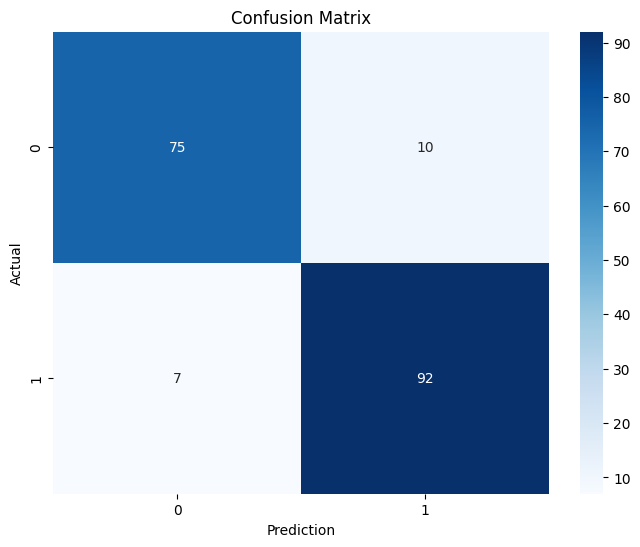

In [562]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

confusion_matrix_result = confusion_matrix(y_test, y_pred)
#making confusion matrix to see whats going wrong

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_result, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

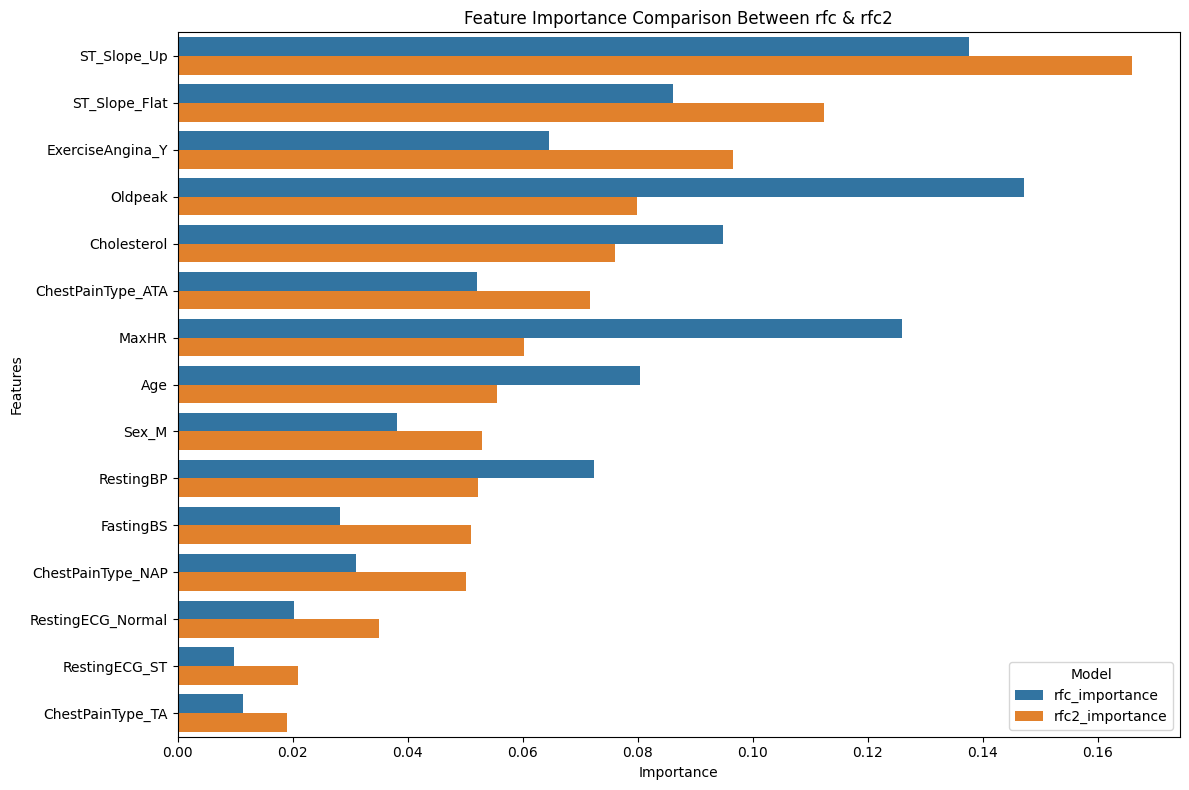

In [574]:

#plot to compare if there is a difference in importance between rfc and rfc2
plot_data = comparison_df.reset_index().melt(id_vars='index', value_vars=['rfc_importance', 'rfc2_importance'],
                                            var_name='Model', value_name='Importance')
plot_data.columns = ['Feature', 'Model', 'Importance']

plt.figure(figsize=(12, 8))
sns.barplot(data=plot_data, y='Feature', x='Importance', hue='Model')
plt.title('Feature Importance Comparison Between rfc & rfc2')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()